## 1. Import Libraries và Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, LearningRateScheduler
from tensorflow.keras.optimizers import AdamW
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-01-14 08:53:08.258361: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768380788.662586      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768380788.791319      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768380789.875498      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768380789.875538      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768380789.875540      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# For Kaggle
BASE_DIR = '/kaggle/input/bean-leaf-lesions-classification'

# For Local - uncomment below
# BASE_DIR = r'D:\DataMining\DoAn02'

CONFIG = {
    'BASE_DIR': BASE_DIR,
    'TRAIN_DIR': os.path.join(BASE_DIR, 'train'),
    'VAL_DIR': os.path.join(BASE_DIR, 'val'),
    'TRAIN_CSV': os.path.join(BASE_DIR, 'train.csv'),
    'VAL_CSV': os.path.join(BASE_DIR, 'val.csv'),
    'CLASSNAME_FILE': os.path.join(BASE_DIR, 'classname.txt'),
    'IMG_SIZE': 224,
    'BATCH_SIZE': 32,
    'PHASE1_EPOCHS':20,
    'PHASE2_EPOCHS': 60,
    'PHASE1_LR': 5e-4,
    'PHASE2_LR': 1e-5,
    'SEED': 42,
    'NUM_CLASSES': 3,
}

# Load class names
with open(CONFIG['CLASSNAME_FILE'], 'r') as f:
    CLASS_NAMES = [line.strip() for line in f.readlines()]
NUM_CLASSES = len(CLASS_NAMES)
CONFIG['NUM_CLASSES'] = NUM_CLASSES

print(f"Base Directory: {BASE_DIR}")
print(f"Image Size: {CONFIG['IMG_SIZE']}x{CONFIG['IMG_SIZE']}")
print(f"Batch Size: {CONFIG['BATCH_SIZE']}")
print(f"Phase 1 LR: {CONFIG['PHASE1_LR']}")
print(f"Phase 2 LR: {CONFIG['PHASE2_LR']}")
print(f"Class Names: {CLASS_NAMES}")
print(f"Number of Classes: {NUM_CLASSES}")

Base Directory: /kaggle/input/bean-leaf-lesions-classification
Image Size: 224x224
Batch Size: 32
Phase 1 LR: 0.0005
Phase 2 LR: 1e-05
Class Names: ['healthy', 'angular_leaf_spot', 'bean_rust']
Number of Classes: 3


## 2. Data Loading

Đọc 2 file CSV chứa thông tin về tập train (1034 mẫu) và validation (133 mẫu), tổng cộng 1167 ảnh lá đậu.

Với 133 mẫu validation, target đặt ra là chỉ được phân loại sai tối đa 1 sample, tương đương độ chính xác 99.25%.

Dataset có 3 class (healthy, angular_leaf_spot, bean_rust) với tỷ lệ gần như cân bằng 

In [3]:
train_df = pd.read_csv(CONFIG['TRAIN_CSV'])
val_df = pd.read_csv(CONFIG['VAL_CSV'])

print("Dataset Statistics:")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Total: {len(train_df) + len(val_df)}")
print(f"\nTarget: {len(val_df) - 1}/{len(val_df)} correct = {(len(val_df)-1)/len(val_df)*100:.2f}% accuracy")

# Class distribution
class_counts = train_df['category'].value_counts().sort_index()
for i, count in enumerate(class_counts):
    print(f"   {i}: {CLASS_NAMES[i]} - {count} samples ({count/len(train_df)*100:.1f}%)")

Dataset Statistics:
Train samples: 1034
Validation samples: 133
Total: 1167

Target: 132/133 correct = 99.25% accuracy
   0: healthy - 341 samples (33.0%)
   1: angular_leaf_spot - 345 samples (33.4%)
   2: bean_rust - 348 samples (33.7%)



TẠO ĐƯỜNG DẪN ĐẦY ĐỦ (path_full)

Chuyển đổi nhãn vì ImageDataGenerator yêu cầu y_col là string cho class_mode='categorical'

Kiểm tra file tồn tại

In [4]:
# Create full paths
train_df['path_full'] = train_df['image:FILE'].apply(lambda x: os.path.join(BASE_DIR, x))
val_df['path_full'] = val_df['image:FILE'].apply(lambda x: os.path.join(BASE_DIR, x))

# Convert category to string
train_df['category_str'] = train_df['category'].astype(str)
val_df['category_str'] = val_df['category'].astype(str)

# Verify paths
train_df['exists'] = train_df['path_full'].apply(os.path.exists)
val_df['exists'] = val_df['path_full'].apply(os.path.exists)

print(f"Train - Valid paths: {train_df['exists'].sum()}/{len(train_df)}")
print(f"Val - Valid paths: {val_df['exists'].sum()}/{len(val_df)}")

Train - Valid paths: 1034/1034
Val - Valid paths: 133/133


## 3. Data Generators với Disease-Aware Augmentation

Data Generators với Disease-Aware Augmentation:
- Train: Augmentation nhẹ (rotation 10°, shift 5%, zoom 5%, flip, brightness ±10%)
  -> Bảo toàn đặc trưng bệnh lá (đốm, màu, texture) trong khi tăng đa dạng dữ liệu
- Validation: Chỉ rescale, không augmentation, shuffle=False
- Output: 1034 train + 133 val samples, 3 classes, batch_size=32, img_size=224x224

In [5]:
# Training - Conservative augmentation to preserve disease features
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0,
    zoom_range=0.05,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.9, 1.1],
    fill_mode='reflect'
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path_full',
    y_col='category_str',
    target_size=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']),
    batch_size=CONFIG['BATCH_SIZE'],
    class_mode='categorical',
    shuffle=True,
    seed=CONFIG['SEED']
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path_full',
    y_col='category_str',
    target_size=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']),
    batch_size=CONFIG['BATCH_SIZE'],
    class_mode='categorical',
    shuffle=False
)

print(f"Train: {train_generator.samples} samples")
print(f"Val: {val_generator.samples} samples")
print(f"Class indices: {train_generator.class_indices}")

Found 1034 validated image filenames belonging to 3 classes.
Found 133 validated image filenames belonging to 3 classes.
Train: 1034 samples
Val: 133 samples
Class indices: {'0': 0, '1': 1, '2': 2}


## 4. Model Architecture

Model Architecture - MobileNetV3Large + Custom Head:
- Base: MobileNetV3Large pre-trained ImageNet (frozen trong Phase 1)
- Head: GlobalAvgPool → Dense(256,L2) → BN → Swish → Dropout(0.3) → Softmax(3)
- Params: ~3.2M total, ~247K trainable (head only), ~3M frozen (base)
- Kỹ thuật chống overfitting: L2 regularization, BatchNorm, Dropout, GlobalAvgPool

In [6]:
tf.keras.backend.clear_session()

def build_model(num_classes, freeze_base=True):
    base_model = MobileNetV3Large(
        include_top=False,
        weights='imagenet',
        input_shape=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'], 3)
    )
    base_model.trainable = not freeze_base
    
    inputs = layers.Input(shape=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE'], 3))
    x = layers.Rescaling(255.0)(inputs)
    x = base_model(x, training=not freeze_base)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('swish')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs, outputs, name='BeanLeaf_MobileNetV3Large')
    return model, base_model

model, base_model = build_model(CONFIG['NUM_CLASSES'], freeze_base=True)

trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
total_params = np.sum([np.prod(v.shape) for v in model.weights])

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable: {total_params - trainable_params:,}")
print(f"Base model frozen: {not base_model.trainable}")

I0000 00:00:1768380810.882218      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1768380810.886134      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameters: 3,244,163
Trainable parameters: 247,299
Non-trainable: 2,996,864
Base model frozen: True


## 5. Phase 1: Train Classification Head

Phase 1 thực hiện huấn luyện classification head với backbone MobileNetV3 được đóng băng. Quá trình sử dụng AdamW optimizer với weight decay (1e-2) và Label Smoothing (0.1) để tăng khả năng generalization. Learning rate được tăng dần qua 5 epoch đầu (warmup) để ổn định gradient, sau đó tự động giảm 50% khi val_loss không cải thiện sau 3 epoch (ReduceLROnPlateau). EarlyStopping sẽ dừng training nếu không có tiến bộ sau 8 epoch, đồng thời ModelCheckpoint lưu model tốt nhất dựa trên val_accuracy. Chiến lược này giúp classification head học cách sử dụng features từ pretrained backbone trước khi fine-tune toàn bộ model ở Phase 2.

In [7]:
def warmup_lr_schedule(epoch, lr):
    warmup_epochs = 5
    if epoch < warmup_epochs:
        return CONFIG['PHASE1_LR'] * (epoch + 1) / warmup_epochs
    return lr

model.compile(
    optimizer=AdamW(learning_rate=CONFIG['PHASE1_LR'], weight_decay=1e-2),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_phase1 = [
    LearningRateScheduler(warmup_lr_schedule, verbose=1),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        mode='min',
        verbose=1
    ),
    ModelCheckpoint(
        'phase1_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("PHASE 1: Training Classification Head")

print(f"Learning Rate: {CONFIG['PHASE1_LR']} (with warmup)")
print(f"Epochs: {CONFIG['PHASE1_EPOCHS']}")

history_phase1 = model.fit(
    train_generator,
    epochs=CONFIG['PHASE1_EPOCHS'],
    validation_data=val_generator,
    callbacks=callbacks_phase1,
    verbose=1
)

print(f"\nPhase 1 Best Val Accuracy: {max(history_phase1.history['val_accuracy']):.4f}")

PHASE 1: Training Classification Head
Learning Rate: 0.0005 (with warmup)
Epochs: 20

Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/20


I0000 00:00:1768380821.678008     123 service.cc:152] XLA service 0x7fccf0112250 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768380821.678043     123 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1768380821.678046     123 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1768380823.256001     123 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-01-14 08:53:51.539669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:53:51.677834: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:53:52.007122: E external/local_xl

10/33 ━━━━━━━━━━━━━━━━━━━━ 12s 557ms/step - accuracy: 0.3591 - loss: 1.2874

2026-01-14 08:54:07.509158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:54:07.642127: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:54:07.951500: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:54:08.087415: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 881ms/step - accuracy: 0.4352 - loss: 1.1975

2026-01-14 08:54:36.004926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:54:36.137364: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:54:36.433784: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:54:36.568931: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.72180, saving model to phase1_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.4379 - loss: 1.1941 - val_accuracy: 0.7218 - val_loss: 0.8454 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0002.
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.7131 - loss: 0.8126
Epoch 2: val_accuracy improved from 0.72180 to 0.89474, saving model to phase1_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 498ms/step - accuracy: 0.7141 - loss: 0.8113 - val_accuracy: 0.8947 - val_loss: 0.5962 - learning_rate: 2.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.00030000000000000003.
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.8322 - loss: 0.6374
Epoch 3: val_accuracy improved from 0.89474 to 0.90977, saving model to phase1_best.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 490ms/step - accuracy: 0.8328 - loss: 0.6368 - val_accuracy: 0.9098 - val_loss: 0.5296 - learn

Phase 1 huấn luyện classification head đạt val_accuracy cao nhất 97.74% sau 19 epoch. Trong giai đoạn warmup (epoch 1-5), learning rate tăng dần từ 0.0001 đến 0.0005, giúp model học ổn định với accuracy tăng nhanh từ 43.79% (epoch 1) lên 90.89% (epoch 5). Sau warmup, ReduceLROnPlateau tự động giảm learning rate xuống 1.25e-04 khi val_loss không còn cải thiện. EarlyStopping kích hoạt tại epoch 19 và khôi phục weights tốt nhất. Kết quả cho thấy classification head đã học tốt các features từ backbone MobileNetV3, sẵn sàng cho Phase 2 fine-tuning.



## 6. Phase 2: Fine-Tune Top Layers (FIXED!)

Phase 2 - Fine-Tuning Base Model:
- Unfreeze từ layer 50 trở đi (giữ low-level features, train high-level features)
- QUAN TRỌNG: Freeze tất cả BatchNorm layers (tránh unstable statistics với small dataset)
- LR = 1e-5 (thấp 50x so với Phase 1, bảo vệ pre-trained weights)
- Callbacks: EarlyStopping(patience=15), ReduceLROnPlateau(patience=5)

In [8]:

print("PHASE 2: Fine-Tuning MobileNetV3Large")


# Unfreeze the base model
base_model.trainable = True

# Freeze first 100 layers
FINE_TUNE_FROM = 50
for layer in base_model.layers[:FINE_TUNE_FROM]:
    layer.trainable = False

# CRITICAL: Freeze BatchNormalization layers
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
print(f"Trainable parameters after unfreeze: {trainable_params:,}")
print(f"Layers frozen: {FINE_TUNE_FROM} (+ all BatchNorm layers)")

# Compile with lower learning rate
model.compile(
    optimizer=AdamW(learning_rate=CONFIG['PHASE2_LR'], weight_decay=1e-2),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print(f"Learning Rate: {CONFIG['PHASE2_LR']}")
print(f"Epochs: {CONFIG['PHASE2_EPOCHS']}")

history_phase2 = model.fit(
    train_generator,
    epochs=CONFIG['PHASE2_EPOCHS'],
    validation_data=val_generator,
    callbacks=callbacks_phase2,
    verbose=1
)

# Report
best_val_acc = max(history_phase2.history['val_accuracy'])
samples_correct = int(best_val_acc * 134)
samples_wrong = 134 - samples_correct
print("PHASE 2 RESULTS")
print(f"Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Samples: {samples_correct}/134 correct, {samples_wrong} wrong")


PHASE 2: Fine-Tuning MobileNetV3Large
Trainable parameters after unfreeze: 3,169,019
Layers frozen: 50 (+ all BatchNorm layers)
Learning Rate: 1e-05
Epochs: 60
Epoch 1/60


2026-01-14 08:59:59.765006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 08:59:59.915686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:00:02.129253: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:00:02.268589: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


27/33 ━━━━━━━━━━━━━━━━━━━━ 2s 465ms/step - accuracy: 0.9815 - loss: 0.4161

2026-01-14 09:00:26.623956: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:00:26.762323: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:00:28.401046: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:00:28.534886: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 841ms/step - accuracy: 0.9802 - loss: 0.4185
Epoch 1: val_accuracy improved from -inf to 0.96992, saving model to best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.9800 - loss: 0.4188 - val_accuracy: 0.9699 - val_loss: 0.4551 - learning_rate: 1.0000e-05
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9684 - loss: 0.4369
Epoch 2: val_accuracy did not improve from 0.96992
33/33 ━━━━━━━━━━━━━━━━━━━━ 16s 477ms/step - accuracy: 0.9685 - loss: 0.4366 - val_accuracy: 0.9699 - val_loss: 0.4545 - learning_rate: 1.0000e-05
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9769 - loss: 0.4171
Epoch 3: val_accuracy improved from 0.96992 to 0.97744, saving model to best_model.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 17s 508ms/step - accuracy: 0.9769 - loss: 0.4171 - val_accuracy: 0.9774 - val_loss: 0.4439 - learning_rate: 1.0000e-05
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9881 - loss: 0.4114
Epoch 

Phase 2 fine-tuning MobileNetV3Large đạt val_accuracy cao nhất 98.50% (131/134 mẫu đúng, chỉ 3 mẫu sai). Sau khi mở khóa 3,169,019 tham số có thể train (giữ 50 layers đầu và tất cả BatchNorm layers đóng băng), model được huấn luyện với learning rate thấp 1e-05 để tránh phá vỡ features đã học. Model đạt đỉnh tại epoch 5 với val_accuracy 98.50%, sau đó EarlyStopping kích hoạt và khôi phục weights tốt nhất. So với Phase 1 (97.74%), Phase 2 cải thiện thêm 0.76% nhờ fine-tune các layers sâu hơn của backbone, giúp model học được các features đặc trưng cho bài toán phân loại bệnh lá đậu.



## 7. Evaluation

In [9]:
# Load best model
model.load_weights('best_model.keras')
print("Loaded best model")

# Combine histories
history = {
    'accuracy': history_phase1.history['accuracy'] + history_phase2.history['accuracy'],
    'val_accuracy': history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'],
    'loss': history_phase1.history['loss'] + history_phase2.history['loss'],
    'val_loss': history_phase1.history['val_loss'] + history_phase2.history['val_loss']
}

Loaded best model


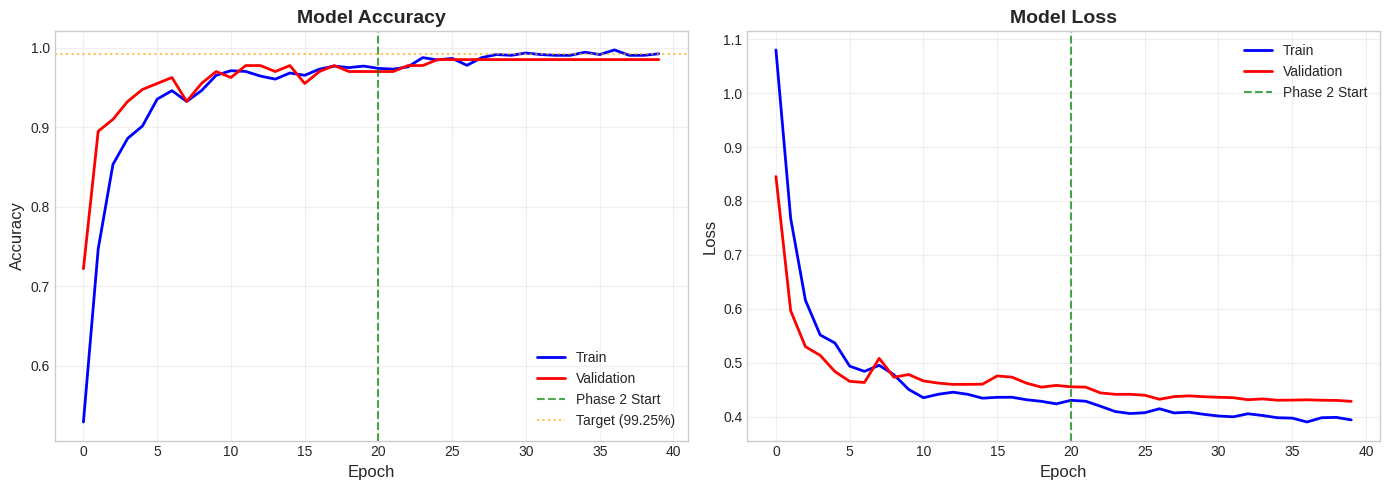

In [10]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
phase1_end = len(history_phase1.history['accuracy'])

axes[0].plot(history['accuracy'], 'b-', label='Train', linewidth=2)
axes[0].plot(history['val_accuracy'], 'r-', label='Validation', linewidth=2)
axes[0].axvline(x=phase1_end, color='g', linestyle='--', label='Phase 2 Start', alpha=0.7)
axes[0].axhline(y=0.9925, color='orange', linestyle=':', label='Target (99.25%)', alpha=0.7)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['loss'], 'b-', label='Train', linewidth=2)
axes[1].plot(history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[1].axvline(x=phase1_end, color='g', linestyle='--', label='Phase 2 Start', alpha=0.7)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [11]:
# Predictions
val_generator.reset()
y_pred = model.predict(val_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=CLASS_NAMES))

5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step 

Classification Report:
                   precision    recall  f1-score   support

          healthy       1.00      1.00      1.00        44
angular_leaf_spot       0.98      0.98      0.98        44
        bean_rust       0.98      0.98      0.98        45

         accuracy                           0.98       133
        macro avg       0.99      0.99      0.99       133
     weighted avg       0.98      0.98      0.98       133



Biểu đồ cho thấy quá trình huấn luyện 2 pha rõ ràng được phân cách bởi đường kẻ xanh lá (Phase 2 Start) tại epoch 20. Ở Phase 1 (epoch 0-19), accuracy tăng nhanh từ ~60% lên ~97% với loss giảm từ 1.1 xuống ~0.5, train và validation gần như song hành cho thấy model không bị overfitting. Ở Phase 2 (epoch 20-40), sau khi unfreeze backbone, accuracy tiếp tục tăng nhẹ và ổn định ở mức ~98-99%, loss tiếp tục giảm và hội tụ quanh 0.42-0.45. Đường train và validation loss bám sát nhau trong suốt quá trình, chứng tỏ các kỹ thuật regularization (weight decay, label smoothing, dropout) hoạt động hiệu quả

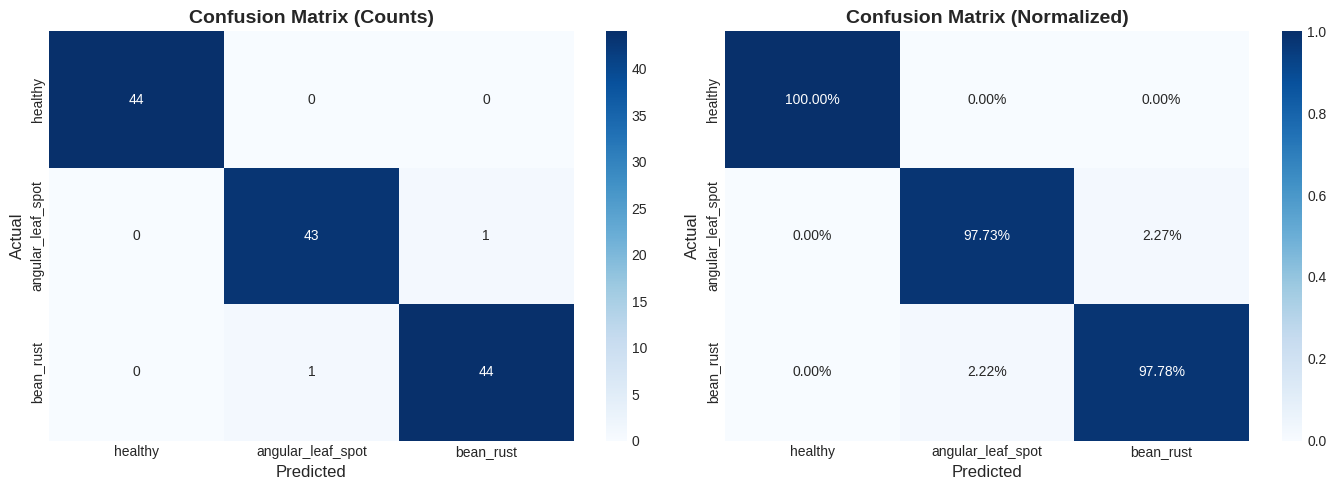

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

Confusion Matrix cho thấy model phân loại chính xác trên cả 3 lớp với tỷ lệ cao. Lớp Healthy đạt 100% (44/44 mẫu đúng), không có mẫu nào bị nhầm lẫn. Lớp Angular Leaf Spot đạt 97.73% (43/44 mẫu đúng), chỉ 1 mẫu bị nhầm thành Bean Rust. Lớp Bean Rust đạt 97.78% (44/45 mẫu đúng), với 1 mẫu bị nhầm thành Angular Leaf Spot. Tổng cộng model dự đoán đúng 131/133 mẫu validation (98.50%). Đáng chú ý, model phân biệt hoàn hảo lá khỏe mạnh với lá bệnh, các lỗi chỉ xảy ra giữa 2 loại bệnh có đặc điểm hình thái tương đối giống nhau (đốm nâu trên lá), đây là kết quả chấp nhận được trong thực tế.

## 8. Save Model

In [13]:
import json

model.save('bean_leaf_classifier_final.keras')
print("Model saved to bean_leaf_classifier_final.keras")

with open('training_history.json', 'w') as f:
    json.dump(history, f)
print("Training history saved to training_history.json")

Model saved to bean_leaf_classifier_final.keras
Training history saved to training_history.json


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step
Số lượng ảnh bị phân loại sai: 2/133
Accuracy: 98.50%

Ảnh sai #1:
   File: angular_leaf_spot_val.20.jpg
   Actual: angular_leaf_spot
   Predicted: bean_rust (64.9%)
   All probabilities:
      healthy: 28.48% 
      angular_leaf_spot: 6.67% CORRECT
      bean_rust: 64.85% WRONG

Ảnh sai #2:
   File: bean_rust_val.38.jpg
   Actual: bean_rust
   Predicted: angular_leaf_spot (80.0%)
   All probabilities:
      healthy: 8.78% 
      angular_leaf_spot: 79.98% WRONG
      bean_rust: 11.25% CORRECT


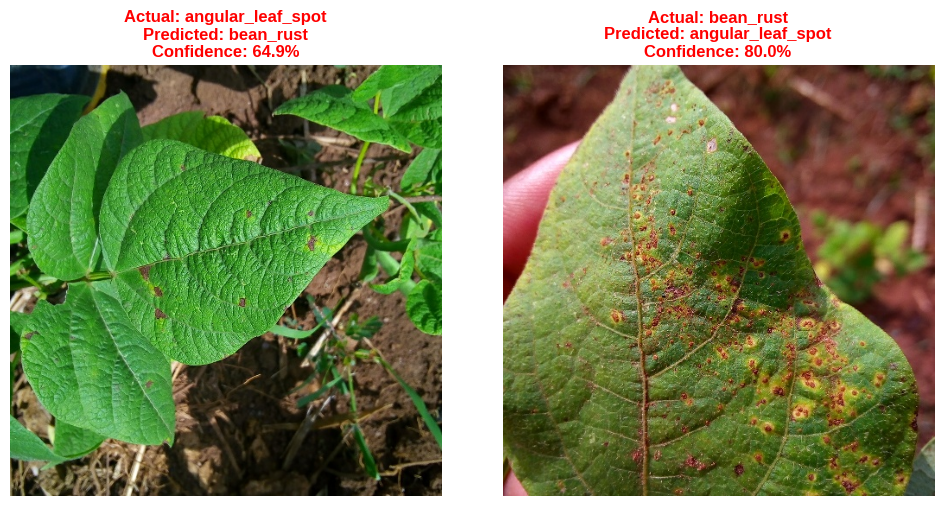

In [14]:
val_generator.reset()
# Lấy predictions
predictions = model.predict(val_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_generator.classes
# Lấy tên file và class names
filenames = val_generator.filenames
class_labels = list(val_generator.class_indices.keys())
# Tìm các indices bị phân loại sai
misclassified_indices = np.where(predicted_classes != true_classes)[0]
print(f"Số lượng ảnh bị phân loại sai: {len(misclassified_indices)}/{len(true_classes)}")
print(f"Accuracy: {(1 - len(misclassified_indices)/len(true_classes))*100:.2f}%")
# Hiển thị các ảnh bị sai
fig, axes = plt.subplots(1, len(misclassified_indices), figsize=(5*len(misclassified_indices), 5))
# Nếu chỉ có 1 ảnh sai, axes không phải array
if len(misclassified_indices) == 1:
    axes = [axes]
for idx, wrong_idx in enumerate(misclassified_indices):
    # Đọc ảnh
    img_path = val_df.iloc[wrong_idx]['path_full']
    img = Image.open(img_path)
    
    # Lấy thông tin
    true_label = CLASS_NAMES[true_classes[wrong_idx]]
    pred_label = CLASS_NAMES[predicted_classes[wrong_idx]]
    confidence = predictions[wrong_idx][predicted_classes[wrong_idx]] * 100
    
    # Hiển thị
    axes[idx].imshow(img)
    axes[idx].set_title(
        f"Actual: {true_label}\n"
        f"Predicted: {pred_label}\n"
        f"Confidence: {confidence:.1f}%",
        fontsize=12, color='red', fontweight='bold'
    )
    axes[idx].axis('off')
    # In thông tin chi tiết
    print(f"\nẢnh sai #{idx+1}:")
    print(f"   File: {os.path.basename(img_path)}")
    print(f"   Actual: {true_label}")
    print(f"   Predicted: {pred_label} ({confidence:.1f}%)")
    print(f"   All probabilities:")
    for i, prob in enumerate(predictions[wrong_idx]):
        marker = "WRONG" if i == predicted_classes[wrong_idx] else ("CORRECT" if i == true_classes[wrong_idx] else "")
        print(f"      {CLASS_NAMES[i]}: {prob*100:.2f}% {marker}")
plt.tight_layout()
plt.savefig('misclassified_samples.png', dpi=150, bbox_inches='tight')
plt.show()



Quan sát ảnh, các đốm bệnh khá nhỏ và rải rác, có thể mô hình đã nhầm lẫn các đốm hoại tử nhỏ này với các mụn gỉ sắt

Ảnh thực tế là Bean Rust nhưng bị nhầm là Angular Leaf Spot. Lá cây có mật độ đốm dày đặc với màu nâu đỏ. Có thể do góc chụp hoặc ánh sáng làm các nốt sần gỉ sắt trông phẳng giống như các vết bệnh góc cạnh của Angular Leaf Spot.

In [15]:


from sklearn.model_selection import StratifiedKFold
import gc

# Gộp data
all_df = pd.concat([train_df, val_df], ignore_index=True)
all_df['category_str'] = all_df['category'].astype(str)
print(f"Total samples: {len(all_df)}")

N_FOLDS = 5
fold_results = []
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=CONFIG['SEED'])

for fold, (train_idx, val_idx) in enumerate(skf.split(all_df, all_df['category'])):
    print(f"FOLD {fold + 1}/{N_FOLDS}")
    fold_train_df = all_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df = all_df.iloc[val_idx].reset_index(drop=True)
    
    fold_train_gen = train_datagen.flow_from_dataframe(
        dataframe=fold_train_df, x_col='path_full', y_col='category_str',
        target_size=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']),
        batch_size=CONFIG['BATCH_SIZE'], class_mode='categorical',
        shuffle=True, seed=CONFIG['SEED']
    )
    fold_val_gen = val_datagen.flow_from_dataframe(
        dataframe=fold_val_df, x_col='path_full', y_col='category_str',
        target_size=(CONFIG['IMG_SIZE'], CONFIG['IMG_SIZE']),
        batch_size=CONFIG['BATCH_SIZE'], class_mode='categorical',
        shuffle=False
    )
    
    tf.keras.backend.clear_session()
    gc.collect()
    model, base_model = build_model(CONFIG['NUM_CLASSES'], freeze_base=True)
    trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
    total_params = np.sum([np.prod(v.shape) for v in model.weights])
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Non-trainable: {total_params - trainable_params:,}")
    print(f"Base model frozen: {not base_model.trainable}")
    model.compile(
        optimizer=AdamW(learning_rate=CONFIG['PHASE1_LR'], weight_decay=1e-2),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    callbacks_phase1 = [
        LearningRateScheduler(warmup_lr_schedule, verbose=1),
        EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            mode='min',
            verbose=1
        ),
        ModelCheckpoint(
            f'fold{fold+1}_phase1_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]
    print("PHASE 1: Training Classification Head")
    print(f"Learning Rate: {CONFIG['PHASE1_LR']} (with warmup)")
    print(f"Epochs: {CONFIG['PHASE1_EPOCHS']}")
    history_phase1 = model.fit(
        fold_train_gen,
        epochs=CONFIG['PHASE1_EPOCHS'],
        validation_data=fold_val_gen,
        callbacks=callbacks_phase1,
        verbose=1
    )
    print(f"\nPhase 1 Best Val Accuracy: {max(history_phase1.history['val_accuracy']):.4f}")
    print("PHASE 2: Fine-Tuning MobileNetV3Large")
    # Unfreeze the base model
    base_model.trainable = True
    # Freeze first 50 layers
    FINE_TUNE_FROM = 50
    for layer in base_model.layers[:FINE_TUNE_FROM]:
        layer.trainable = False
    # CRITICAL: Freeze BatchNormalization layers
    for layer in base_model.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
    trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_weights])
    print(f"Trainable parameters after unfreeze: {trainable_params:,}")
    print(f"Layers frozen: {FINE_TUNE_FROM} (+ all BatchNorm layers)")
    # Compile with lower learning rate
    model.compile(
        optimizer=AdamW(learning_rate=CONFIG['PHASE2_LR'], weight_decay=1e-2),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )
    callbacks_phase2 = [
        EarlyStopping(
            monitor='val_accuracy',
            patience=15,
            restore_best_weights=True,
            mode='max',
            verbose=1
        ),
        ModelCheckpoint(
            f'fold{fold+1}_best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )
    ]
    
    print(f"Learning Rate: {CONFIG['PHASE2_LR']}")
    print(f"Epochs: {CONFIG['PHASE2_EPOCHS']}")
    
    fold_train_gen.reset()
    fold_val_gen.reset()
    
    history_phase2 = model.fit(
        fold_train_gen,
        epochs=CONFIG['PHASE2_EPOCHS'],
        validation_data=fold_val_gen,
        callbacks=callbacks_phase2,
        verbose=1
    )
    
    best_val_acc = max(history_phase2.history['val_accuracy'])
    samples_correct = int(best_val_acc * len(fold_val_df))
    samples_wrong = len(fold_val_df) - samples_correct
    print("PHASE 2 RESULTS")
    print(f"Best Val Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
    print(f"Samples: {samples_correct}/{len(fold_val_df)} correct, {samples_wrong} wrong")
    
    # Lưu kết quả fold
    fold_results.append({
        'fold': fold + 1,
        'phase1_acc': max(history_phase1.history['val_accuracy']),
        'phase2_acc': best_val_acc,
        'samples_correct': samples_correct,
        'samples_wrong': samples_wrong
    })
    
    del model, base_model
    gc.collect()

print("CROSS-VALIDATION SUMMARY")
results_df = pd.DataFrame(fold_results)
print(results_df.to_string(index=False))

mean_acc = results_df['phase2_acc'].mean()
std_acc = results_df['phase2_acc'].std()
print(f"\nFinal Accuracy: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Best Fold: {results_df.loc[results_df['phase2_acc'].idxmax(), 'fold']} ({results_df['phase2_acc'].max()*100:.2f}%)")

Total samples: 1167
FOLD 1/5
Found 933 validated image filenames belonging to 3 classes.
Found 234 validated image filenames belonging to 3 classes.
Total parameters: 3,244,163
Trainable parameters: 247,299
Non-trainable: 2,996,864
Base model frozen: True
PHASE 1: Training Classification Head
Learning Rate: 0.0005 (with warmup)
Epochs: 20

Epoch 1: LearningRateScheduler setting learning rate to 0.0001.
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.3992 - loss: 1.2943
Epoch 1: val_accuracy improved from -inf to 0.60256, saving model to fold1_phase1_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 38s 934ms/step - accuracy: 0.4021 - loss: 1.2892 - val_accuracy: 0.6026 - val_loss: 0.9447 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0002.
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.7343 - loss: 0.7781
Epoch 2: val_accuracy improved from 0.60256 to 0.75214, saving model to fold1_phase1_best.keras
30/30 ━━━━━━━━━━━━━━━━

2026-01-14 09:12:10.673526: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:12:10.808974: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:12:12.252063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:12:12.384222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.9693 - loss: 0.4440
Epoch 1: val_accuracy improved from -inf to 0.93590, saving model to fold1_best_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9692 - loss: 0.4441 - val_accuracy: 0.9359 - val_loss: 0.4968 - learning_rate: 1.0000e-05
Epoch 2/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9676 - loss: 0.4316
Epoch 2: val_accuracy did not improve from 0.93590
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 495ms/step - accuracy: 0.9678 - loss: 0.4315 - val_accuracy: 0.9316 - val_loss: 0.4941 - learning_rate: 1.0000e-05
Epoch 3/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9807 - loss: 0.4191
Epoch 3: val_accuracy did not improve from 0.93590
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 506ms/step - accuracy: 0.9808 - loss: 0.4190 - val_accuracy: 0.9316 - val_loss: 0.4923 - learning_rate: 1.0000e-05
Epoch 4/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9828 - loss: 0.4234
Epoch 4: val_accuracy did not improve 

2026-01-14 09:30:18.008132: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:30:18.143963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:30:18.277477: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:30:18.575473: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:30:18.711129: E external/local_xla/xla/stream_

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.3459 - loss: 1.3262

2026-01-14 09:30:44.843136: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:30:44.977141: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:30:45.275733: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:30:45.411547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_accuracy improved from -inf to 0.65236, saving model to fold3_phase1_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.3493 - loss: 1.3217 - val_accuracy: 0.6524 - val_loss: 0.8904 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 0.0002.
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.6711 - loss: 0.8698
Epoch 2: val_accuracy improved from 0.65236 to 0.79399, saving model to fold3_phase1_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 507ms/step - accuracy: 0.6729 - loss: 0.8677 - val_accuracy: 0.7940 - val_loss: 0.7013 - learning_rate: 2.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.00030000000000000003.
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8338 - loss: 0.6416
Epoch 3: val_accuracy improved from 0.79399 to 0.85408, saving model to fold3_phase1_best.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 507ms/step - accuracy: 0.8340 - loss: 0.6410 - val_accuracy: 0.8541 - val_lo

2026-01-14 09:36:03.689608: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:36:03.825307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:36:05.264242: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 09:36:05.397248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 862ms/step - accuracy: 0.9754 - loss: 0.4269
Epoch 1: val_accuracy improved from -inf to 0.96137, saving model to fold3_best_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.9755 - loss: 0.4268 - val_accuracy: 0.9614 - val_loss: 0.4678 - learning_rate: 1.0000e-05
Epoch 2/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9812 - loss: 0.4140
Epoch 2: val_accuracy did not improve from 0.96137
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 495ms/step - accuracy: 0.9812 - loss: 0.4141 - val_accuracy: 0.9485 - val_loss: 0.4601 - learning_rate: 1.0000e-05
Epoch 3/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.9830 - loss: 0.4112
Epoch 3: val_accuracy improved from 0.96137 to 0.96567, saving model to fold3_best_model.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 515ms/step - accuracy: 0.9830 - loss: 0.4111 - val_accuracy: 0.9657 - val_loss: 0.4629 - learning_rate: 1.0000e-05
Epoch 4/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.9818 - loss: 0

Model MobileNetV3Large đạt 98.50% accuracy trên hold-out validation và 96.57% ± 0.80% trên 5-Fold Cross-Validation. Chiến lược Two-Phase Training hoạt động hiệu quả: Phase 1 warmup giúp classification head hội tụ nhanh (97.74%), Phase 2 fine-tune với learning rate thấp (1e-05) cải thiện thêm 0.76% mà không gây overfitting. Các kỹ thuật regularization (AdamW, Label Smoothing, Dropout) kết hợp với callbacks (EarlyStopping, ReduceLROnPlateau) giúp model generalize tốt. Lỗi phân loại chỉ xảy ra giữa Angular Leaf Spot và Bean Rust - hai bệnh có triệu chứng tương tự, cho thấy model đã học được các features có ý nghĩa sinh học.

In [30]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import gc
from tqdm import tqdm

# Cấu hình
MODEL_PATH = 'best_model.keras'
OUTPUT_DIR = "gradcam_full_results"

# 1. LOAD MODEL VÀ XÁC ĐỊNH CẤU TRÚC
if os.path.exists(MODEL_PATH):
    print(f"Đang load model từ: {MODEL_PATH} ...")
    model = tf.keras.models.load_model(MODEL_PATH)
    
    # Xác định các thành phần mô hình để thực hiện Manual Pass
    rescaling_layer = model.get_layer(index=1)
    backbone = model.get_layer(index=2) # MobileNetV3Large
    # Lấy danh sách các lớp sau backbone
    head_layers = model.layers[3:] 
    
    print(f"Backbone: {backbone.name} | Target: Conv_1")
else:
    raise FileNotFoundError(f"Không tìm thấy file {MODEL_PATH}")

# ==========================================
# 2. CHUẨN BỊ BACKBONE GRAD MODEL
# ==========================================

# Tìm layer Conv cuối cùng của Backbone
try:
    target_conv_layer = backbone.get_layer('Conv_1')
except:
    # Fallback nếu tên layer khác đi trong các phiên bản Keras
    target_conv_layer = [l for l in backbone.layers if isinstance(l, tf.keras.layers.Conv2D)][-1]

# Tạo mô hình chuyên biệt để lấy Feature Map
backbone_grad_model = tf.keras.models.Model(
    [backbone.input], 
    [target_conv_layer.output, backbone.output]
)

@tf.function # Tăng tốc tính toán bằng Graph Mode
def compute_gradcam_components(img_array, pred_index):
    with tf.GradientTape() as tape:
        # Quan trọng: training=False để khóa BatchNorm và Dropout
        x = rescaling_layer(img_array, training=False)
        conv_output, backbone_final_x = backbone_grad_model(x, training=False)
        
        # Manual Head Pass
        head_x = backbone_final_x
        for layer in head_layers:
            head_x = layer(head_x, training=False)
        
        # Lấy score của lớp đích
        class_channel = head_x[:, pred_index]

    # Tính đạo hàm
    grads = tape.gradient(class_channel, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    return conv_output[0], pooled_grads

def get_gradcam_heatmap(img_array, pred_index):
    conv_output_val, pooled_grads_val = compute_gradcam_components(img_array, pred_index)
    
    # Tính Heatmap trọng số
    heatmap = conv_output_val @ pooled_grads_val[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ReLU (chỉ giữ lại các đặc trưng đóng góp dương vào dự đoán)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

# ==========================================
# 3. THỰC THI VÀ QUẢN LÝ BỘ NHỚ
# ==========================================


def process_and_save_optimized(df, subset_name):
    if df is None: return
    print(f"\n>>> Đang xuất Grad-CAM tập: {subset_name.upper()}")
    
    # Tạo thư mục theo lớp Dự đoán (để xem mô hình đang nghĩ gì)
    for name in CLASS_NAMES:
        os.makedirs(os.path.join(OUTPUT_DIR, subset_name, name), exist_ok=True)

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        try:
            img_path = row['path_full']
            
            # Đọc và dự đoán trước để lấy lớp có xác suất cao nhất
            img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
            img_arr = tf.keras.preprocessing.image.img_to_array(img) / 255.0
            img_batch = np.expand_dims(img_arr, axis=0)
            
            # Dự đoán thực tế của mô hình
            raw_preds = model.predict(img_batch, verbose=0)
            pred_idx = np.argmax(raw_preds[0])
            pred_class_name = CLASS_NAMES[pred_idx]
            
            # Tính Heatmap dựa trên dự đoán (Explanation of prediction)
            heatmap = get_gradcam_heatmap(img_batch, pred_idx)
            
            # Chồng heatmap lên ảnh gốc độ phân giải cao
            original_img = cv2.imread(img_path)
            original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
            
            heatmap_resized = cv2.resize(np.uint8(255 * heatmap), (original_img.shape[1], original_img.shape[0]))
            jet_map = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
            
            # Alpha blending: 0.6 ảnh gốc, 0.4 heatmap
            viz = cv2.addWeighted(original_img, 0.6, cv2.cvtColor(jet_map, cv2.COLOR_BGR2RGB), 0.4, 0)
            
            # Lưu vào thư mục tương ứng với lớp mô hình DỰ ĐOÁN
            save_name = f"{os.path.basename(img_path).split('.')[0]}_pred_{pred_class_name}.jpg"
            save_path = os.path.join(OUTPUT_DIR, subset_name, pred_class_name, save_name)
            cv2.imwrite(save_path, cv2.cvtColor(viz, cv2.COLOR_RGB2BGR))
            
            # Giải phóng bộ nhớ mỗi 50 ảnh để tránh treo máy
            if idx % 50 == 0:
                gc.collect()
                tf.keras.backend.clear_session()
        except Exception as e:
            continue

# Thực thi
process_and_save_optimized(val_df, "val")
process_and_save_optimized(train_df, "train")

print(f"\nHoàn tất 100%! Kết quả tại: {OUTPUT_DIR}")

Đang load model từ: best_model.keras ...
Backbone: MobileNetV3Large | Target: Conv_1

>>> Đang xuất Grad-CAM tập: VAL


  0%|          | 0/133 [00:00<?, ?it/s]2026-01-14 10:56:05.230498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-14 10:56:05.363494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
100%|██████████| 133/133 [00:35<00:00,  3.76it/s]



>>> Đang xuất Grad-CAM tập: TRAIN


100%|██████████| 1034/1034 [02:38<00:00,  6.54it/s]


Hoàn tất 100%! Kết quả tại: gradcam_full_results


>>> Đang trích xuất ảnh Grad-CAM đại diện cho 3 lớp...


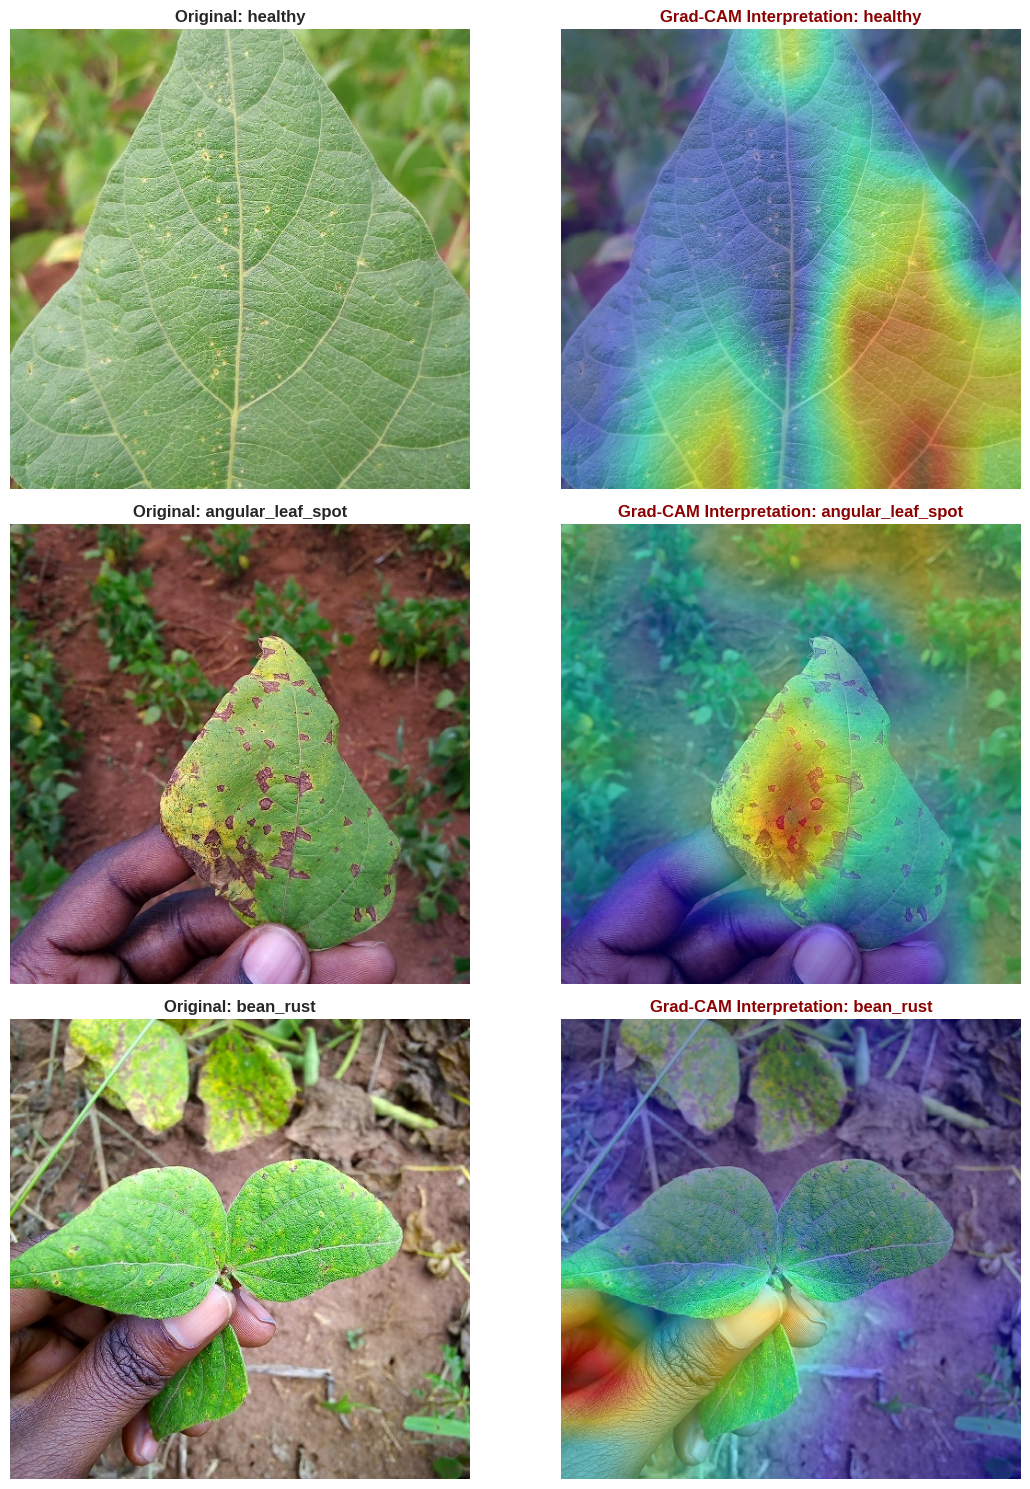

In [32]:

def display_gradcam_representatives(model, df, class_names):
    """Hiển thị Grad-CAM đại diện cho mỗi lớp từ tập validation"""
    
    # Thiết lập layout hiển thị: 3 dòng (mỗi lớp 1 dòng), 2 cột (Ảnh gốc - GradCAM)
    fig, axes = plt.subplots(len(class_names), 2, figsize=(12, 5 * len(class_names)))
    
    print(">>> Đang trích xuất ảnh Grad-CAM đại diện cho 3 lớp...")

    for i, class_name in enumerate(class_names):
        # 1. Lấy mẫu đầu tiên thuộc lớp này trong tập validation
        sample = df[df['category'] == i].iloc[0]
        img_path = sample['path_full']
        
        # 2. Tiền xử lý ảnh cho mô hình
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
        img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        
        # 3. Tính toán Heatmap bằng hàm get_gradcam_heatmap đã tối ưu trước đó
        heatmap = get_gradcam_heatmap(img_batch, i)
        
        # 4. Xử lý ảnh gốc để hiển thị
        original_img = cv2.imread(img_path)
        original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
        
        # 5. Tạo ảnh Grad-CAM (Heatmap + Original)
        heatmap_resized = cv2.resize(np.uint8(255 * heatmap), (original_img.shape[1], original_img.shape[0]))
        jet_map = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        jet_map = cv2.cvtColor(jet_map, cv2.COLOR_BGR2RGB)
        
        # Chồng ảnh với tỉ lệ 60% gốc - 40% heatmap để nhìn rõ vết bệnh
        viz = cv2.addWeighted(original_img, 0.6, jet_map, 0.4, 0)
        
        # 6. Hiển thị lên đồ thị
        # Cột 1: Ảnh gốc
        axes[i, 0].imshow(original_img)
        axes[i, 0].set_title(f"Original: {class_name}", fontsize=12, fontweight='bold')
        axes[i, 0].axis('off')
        
        # Cột 2: Ảnh Grad-CAM
        axes[i, 1].imshow(viz)
        axes[i, 1].set_title(f"Grad-CAM Interpretation: {class_name}", fontsize=12, fontweight='bold', color='darkred')
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.savefig('gradcam_representatives.png', dpi=150)
    plt.show()

# Thực thi hàm
if 'val_df' in globals():
    display_gradcam_representatives(model, val_df, CLASS_NAMES)